# Part 10 — Error Analysis

Analyze **where and why** the four trained HAM10000 models make mistakes. **No retraining** is performed. The notebook reloads the best checkpoints and evaluates them on the same fixed `data/processed/test.csv` used in Part 9.


In [1]:
from pathlib import Path
import inspect, math, random, sys, warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import yaml
from PIL import Image
from sklearn.metrics import ConfusionMatrixDisplay
from torch.utils.data import DataLoader
from torchvision import transforms
warnings.filterwarnings("ignore")
cwd=Path.cwd(); PROJECT_ROOT=cwd if (cwd/"src").exists() else cwd.parent
if not (PROJECT_ROOT/"src").exists(): raise FileNotFoundError("Run from project root or notebooks/")
if str(PROJECT_ROOT) not in sys.path: sys.path.insert(0,str(PROJECT_ROOT))
SEED=42; random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PROJECT_ROOT:",PROJECT_ROOT); print("Device:",device)


PROJECT_ROOT: c:\Deep Learning\skin-lesion-classification
Device: cpu


In [2]:
CONFIG_PATH=PROJECT_ROOT/"configs/error_analysis.yaml"
with open(CONFIG_PATH,"r",encoding="utf-8") as f: cfg=yaml.safe_load(f)
CLASS_NAMES=cfg["classes"]; CLASS_TO_IDX={c:i for i,c in enumerate(CLASS_NAMES)}; IDX_TO_CLASS={i:c for c,i in CLASS_TO_IDX.items()}
TEST_CSV=PROJECT_ROOT/cfg["paths"]["test_csv"]; CHECKPOINT_DIR=PROJECT_ROOT/cfg["paths"]["checkpoint_dir"]
TABLE_DIR=PROJECT_ROOT/cfg["paths"]["output_tables_dir"]; FIGURE_DIR=PROJECT_ROOT/cfg["paths"]["output_figures_dir"]
TABLE_DIR.mkdir(parents=True,exist_ok=True); FIGURE_DIR.mkdir(parents=True,exist_ok=True)
HIGH_CONF_THRESHOLD=float(cfg["thresholds"]["high_confidence_error"]); LOW_CONF_THRESHOLD=float(cfg["thresholds"]["low_confidence_prediction"])
print(CLASS_TO_IDX)


{'akiec': 0, 'bcc': 1, 'bkl': 2, 'df': 3, 'mel': 4, 'nv': 5, 'vasc': 6}


In [3]:
from src.evaluation.error_analysis import ErrorAnalysisDataset, build_prediction_dataframe, class_error_summary, collect_predictions, common_confusion_pairs, confusion_count_matrix, error_overview, high_confidence_errors, load_model_weights, low_confidence_predictions, normalized_confusion_matrix, resolve_image_path, save_error_analysis_tables


In [4]:
test_df=pd.read_csv(TEST_CSV)
required={"dx","image_id"}; missing=required-set(test_df.columns)
if missing: raise ValueError(f"Missing columns: {missing}")
unknown=sorted(set(test_df.dx.unique())-set(CLASS_NAMES))
if unknown: raise ValueError(f"Unknown labels: {unknown}")
print("Test samples:",len(test_df)); display(test_df.dx.value_counts().reindex(CLASS_NAMES))


Test samples: 1502


dx
akiec      52
bcc        71
bkl       167
df         20
mel       167
nv       1004
vasc       21
Name: count, dtype: int64

In [5]:
IMAGE_SIZE=int(cfg["image_size"]); DATA_ROOT=PROJECT_ROOT/"data"
test_transform=transforms.Compose([transforms.Resize((IMAGE_SIZE,IMAGE_SIZE)),transforms.ToTensor(),transforms.Normalize(mean=[0.485,0.456,0.406],std=[0.229,0.224,0.225])])
test_dataset=ErrorAnalysisDataset(test_df,test_transform,DATA_ROOT,CLASS_TO_IDX)
test_loader=DataLoader(test_dataset,batch_size=int(cfg["batch_size"]),shuffle=False,num_workers=int(cfg["num_workers"]),pin_memory=torch.cuda.is_available())
print("Batches:",len(test_loader))
for i in range(min(3,len(test_df))): print(resolve_image_path(test_df.iloc[i],DATA_ROOT))


Batches: 47
C:\Deep Learning\skin-lesion-classification\data\raw\HAM10000_images_part_1\ISIC_0029176.jpg
C:\Deep Learning\skin-lesion-classification\data\raw\HAM10000_images_part_1\ISIC_0029068.jpg
C:\Deep Learning\skin-lesion-classification\data\raw\HAM10000_images_part_1\ISIC_0025837.jpg


In [6]:
from src.models.simple_cnn import SimpleCNN
from src.models.complex_cnn import ComplexCNN
from src.models.transfer_learning import TransferLearningResNet18
def construct(cls,**kwargs):
    p=inspect.signature(cls.__init__).parameters; return cls(**{k:v for k,v in kwargs.items() if k in p})
MODEL_BUILDERS={
 "Simple CNN":lambda:construct(SimpleCNN,num_classes=7,dropout=.5),
 "Complex CNN":lambda:construct(ComplexCNN,num_classes=7,dropout=.5),
 "Transfer Learning ResNet18":lambda:construct(TransferLearningResNet18,num_classes=7,dropout=.3,pretrained=False,freeze_backbone=True),
 "Fine-tuned ResNet18":lambda:construct(TransferLearningResNet18,num_classes=7,dropout=.3,pretrained=False,freeze_backbone=False),
}
CHECKPOINTS={n:CHECKPOINT_DIR/f for n,f in cfg["checkpoints"].items()}
for n,p in CHECKPOINTS.items(): print(n,p,p.exists())


Simple CNN c:\Deep Learning\skin-lesion-classification\outputs\checkpoints\simple_cnn_best.pt True
Complex CNN c:\Deep Learning\skin-lesion-classification\outputs\checkpoints\complex_cnn_best.pt True
Transfer Learning ResNet18 c:\Deep Learning\skin-lesion-classification\outputs\checkpoints\transfer_resnet18_best.pt True
Fine-tuned ResNet18 c:\Deep Learning\skin-lesion-classification\outputs\checkpoints\fine_tuned_resnet18_best.pt True


In [8]:
models={}
for name,builder in MODEL_BUILDERS.items():
    model = builder()
    ckpt = torch.load(
        CHECKPOINTS[name],
        map_location=device,
        weights_only=False,  # required for legacy checkpoints on PyTorch >= 2.6
    )
    state_dict = ckpt.get("state_dict", ckpt) if isinstance(ckpt, dict) else ckpt
    if isinstance(state_dict, dict):
        state_dict = {k.replace("module.", ""): v for k, v in state_dict.items()}
    model.load_state_dict(state_dict, strict=True)
    model.to(device)
    model.eval()
    models[name] = model
    print("Loaded:", name)


Loaded: Simple CNN
Loaded: Complex CNN
Loaded: Transfer Learning ResNet18
Loaded: Fine-tuned ResNet18


## 1. Collect predictions
Store true labels, predicted labels, 7-class probabilities, confidence, and sample index for every test image.


In [9]:
prediction_outputs={}; prediction_tables={}
for name,model in models.items():
    out=collect_predictions(model,test_loader,device); prediction_outputs[name]=out
    df=build_prediction_dataframe(test_df,out,IDX_TO_CLASS); prediction_tables[name]=df
    print(name,error_overview(df))


Simple CNN {'n_samples': 1502, 'n_correct': 902, 'n_errors': 600, 'accuracy': 0.6005326231691078, 'error_rate': 0.3994673768308921, 'mean_confidence': 0.5998779535293579, 'mean_error_confidence': 0.41947677731513977}
Complex CNN {'n_samples': 1502, 'n_correct': 1087, 'n_errors': 415, 'accuracy': 0.7237017310252996, 'error_rate': 0.2762982689747004, 'mean_confidence': 0.6017138361930847, 'mean_error_confidence': 0.41910865902900696}
Transfer Learning ResNet18 {'n_samples': 1502, 'n_correct': 1114, 'n_errors': 388, 'accuracy': 0.7416777629826897, 'error_rate': 0.2583222370173103, 'mean_confidence': 0.5840399265289307, 'mean_error_confidence': 0.4288927912712097}
Fine-tuned ResNet18 {'n_samples': 1502, 'n_correct': 1155, 'n_errors': 347, 'accuracy': 0.7689747003994674, 'error_rate': 0.2310252996005326, 'mean_confidence': 0.6912859678268433, 'mean_error_confidence': 0.5118180513381958}


## 2. Overall error comparison


,model,n_samples,n_correct,n_errors,accuracy,error_rate,mean_confidence,mean_error_confidence
0,Fine-tuned ResNet18,1502,1155,347,0.768975,0.231025,0.691286,0.511818
1,Transfer Learning ResNet18,1502,1114,388,0.741678,0.258322,0.584040,0.428893
2,Complex CNN,1502,1087,415,0.723702,0.276298,0.601714,0.419109
3,Simple CNN,1502,902,600,0.600533,0.399467,0.599878,0.419477


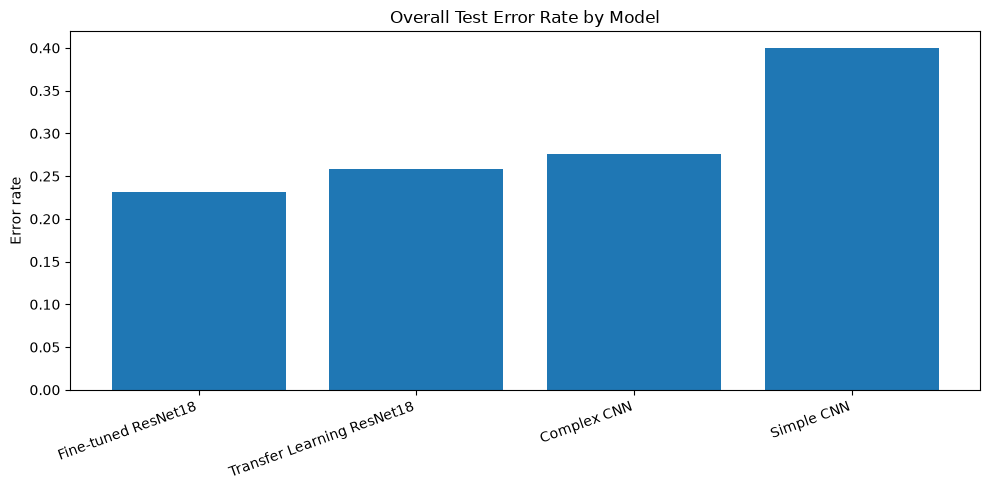

In [10]:
rows=[]
for name,df in prediction_tables.items():
    r={"model":name}; r.update(error_overview(df)); rows.append(r)
error_comparison_df=pd.DataFrame(rows).sort_values("error_rate").reset_index(drop=True); display(error_comparison_df)
error_comparison_df.to_csv(TABLE_DIR/"model_error_overview.csv",index=False)
plt.figure(figsize=(10,5)); plt.bar(error_comparison_df.model,error_comparison_df.error_rate); plt.ylabel("Error rate"); plt.title("Overall Test Error Rate by Model"); plt.xticks(rotation=20,ha="right"); plt.tight_layout(); plt.savefig(FIGURE_DIR/"model_error_rate_comparison.png",dpi=200,bbox_inches="tight"); plt.show()


## 3. Per-class error analysis



 Simple CNN


,class,n_samples,n_correct,n_errors,accuracy,error_rate,mean_confidence,mean_confidence_on_errors
0,akiec,52,32,20,0.615385,0.384615,0.374967,0.324841
1,bcc,71,24,47,0.338028,0.661972,0.360895,0.363015
2,bkl,167,79,88,0.473054,0.526946,0.433442,0.429912
3,df,20,3,17,0.150000,0.850000,0.414158,0.397879
4,mel,167,100,67,0.598802,0.401198,0.475833,0.458249
5,nv,1004,651,353,0.648406,0.351594,0.679408,0.423020
6,vasc,21,13,8,0.619048,0.380952,0.649407,0.437804



 Complex CNN


,class,n_samples,n_correct,n_errors,accuracy,error_rate,mean_confidence,mean_confidence_on_errors
0,akiec,52,16,36,0.307692,0.692308,0.363481,0.368899
1,bcc,71,40,31,0.563380,0.436620,0.397982,0.346704
2,bkl,167,67,100,0.401198,0.598802,0.437658,0.464856
3,df,20,0,20,0.000000,1.000000,0.405656,0.405656
4,mel,167,53,114,0.317365,0.682635,0.445543,0.469818
5,nv,1004,898,106,0.894422,0.105578,0.685732,0.364841
6,vasc,21,13,8,0.619048,0.380952,0.596867,0.383852



 Transfer Learning ResNet18


,class,n_samples,n_correct,n_errors,accuracy,error_rate,mean_confidence,mean_confidence_on_errors
0,akiec,52,18,34,0.346154,0.653846,0.362585,0.373685
1,bcc,71,42,29,0.591549,0.408451,0.445994,0.392820
2,bkl,167,72,95,0.431138,0.568862,0.430515,0.437392
3,df,20,0,20,0.000000,1.000000,0.338600,0.338600
4,mel,167,71,96,0.425150,0.574850,0.474669,0.486781
5,nv,1004,898,106,0.894422,0.105578,0.655010,0.409165
6,vasc,21,13,8,0.619048,0.380952,0.530471,0.485839



 Fine-tuned ResNet18


,class,n_samples,n_correct,n_errors,accuracy,error_rate,mean_confidence,mean_confidence_on_errors
0,akiec,52,34,18,0.653846,0.346154,0.594847,0.494025
1,bcc,71,47,24,0.661972,0.338028,0.631872,0.527408
2,bkl,167,80,87,0.479042,0.520958,0.532263,0.516226
3,df,20,8,12,0.400000,0.600000,0.538165,0.440506
4,mel,167,96,71,0.574850,0.425150,0.589676,0.541304
5,nv,1004,875,129,0.871514,0.128486,0.744581,0.496860
6,vasc,21,15,6,0.714286,0.285714,0.801419,0.554245


model,Complex CNN,Fine-tuned ResNet18,Simple CNN,Transfer Learning ResNet18
class,,,,
akiec,0.692308,0.346154,0.384615,0.653846
bcc,0.436620,0.338028,0.661972,0.408451
bkl,0.598802,0.520958,0.526946,0.568862
df,1.000000,0.600000,0.850000,1.000000
mel,0.682635,0.425150,0.401198,0.574850
nv,0.105578,0.128486,0.351594,0.105578
vasc,0.380952,0.285714,0.380952,0.380952


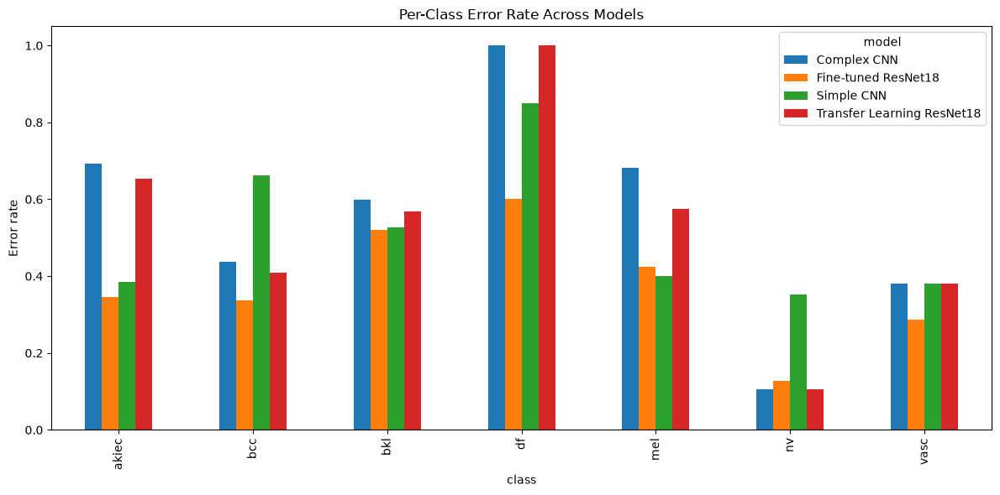

In [11]:
class_error_tables={}
for name,df in prediction_tables.items():
    s=class_error_summary(df,CLASS_NAMES); class_error_tables[name]=s; print("\n",name); display(s)
combined=[]
for name,s in class_error_tables.items():
    t=s[["class","n_samples","n_errors","error_rate"]].copy(); t["model"]=name; combined.append(t)
pivot=pd.concat(combined).pivot(index="class",columns="model",values="error_rate").reindex(CLASS_NAMES); display(pivot); pivot.to_csv(TABLE_DIR/"per_class_error_rate_comparison.csv")
ax=pivot.plot(kind="bar",figsize=(12,6)); ax.set_ylabel("Error rate"); ax.set_title("Per-Class Error Rate Across Models"); plt.tight_layout(); plt.savefig(FIGURE_DIR/"per_class_error_rate_comparison.png",dpi=200,bbox_inches="tight"); plt.show()


## 4. Raw and normalized confusion matrices


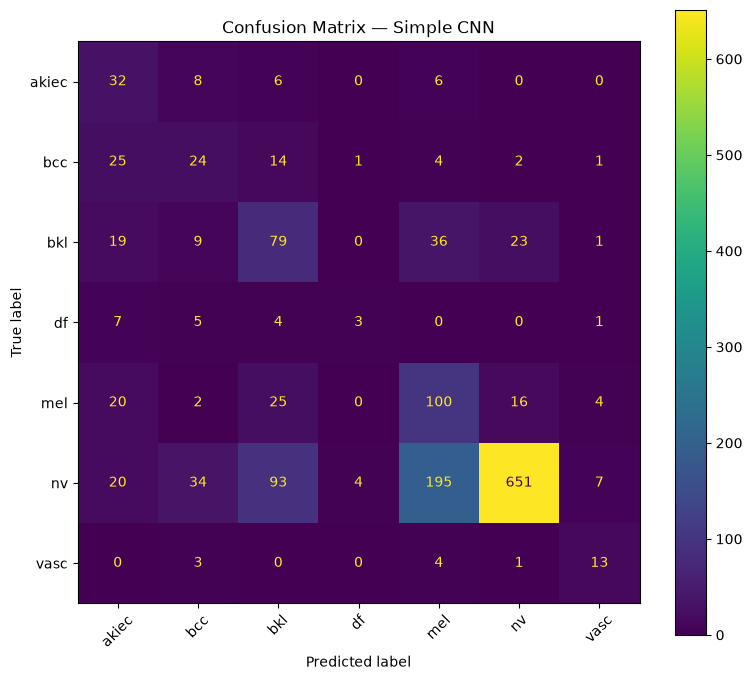

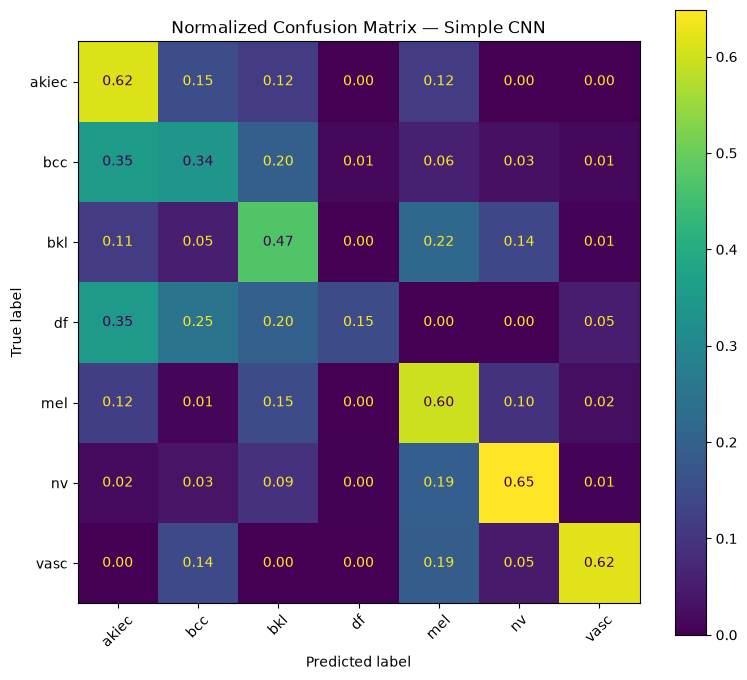

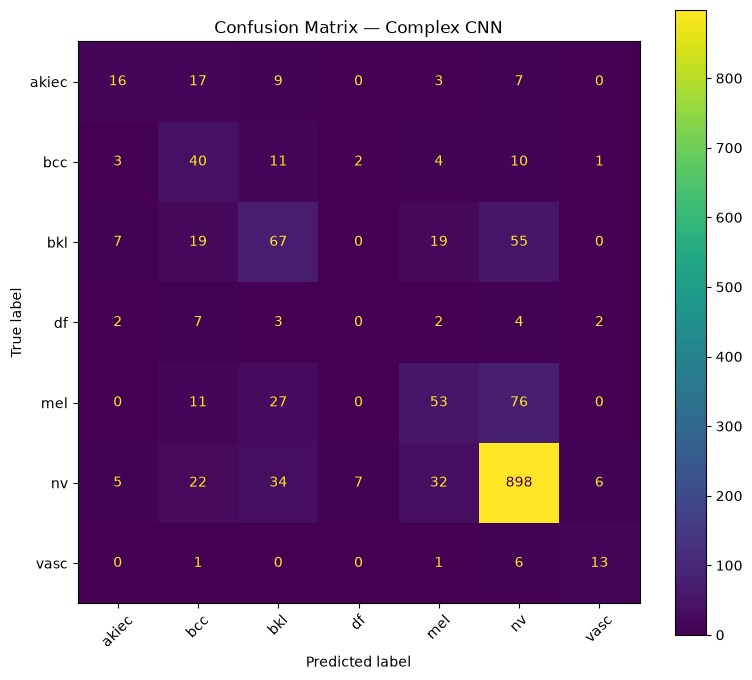

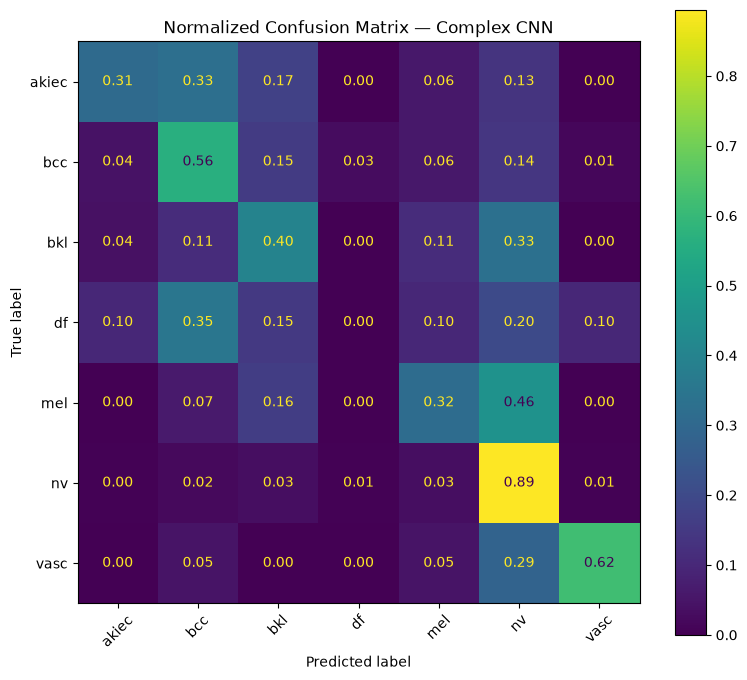

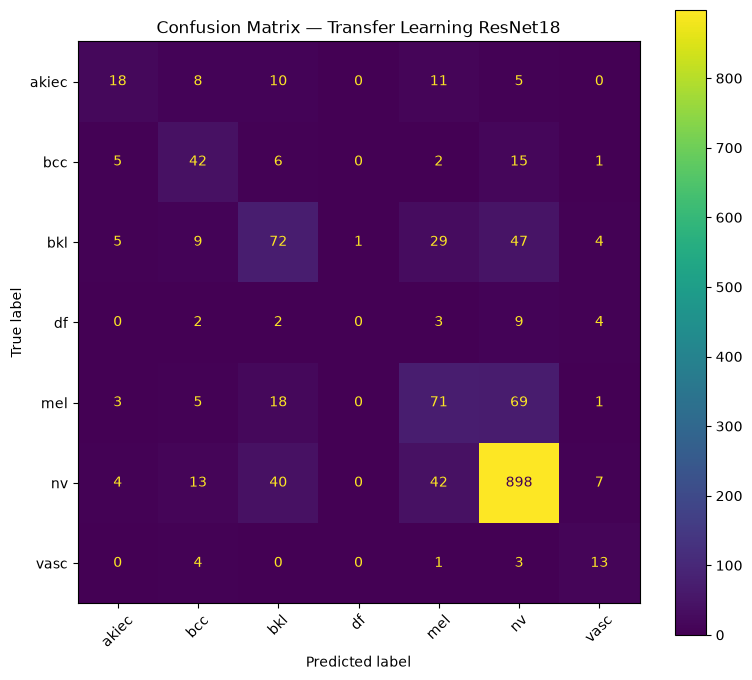

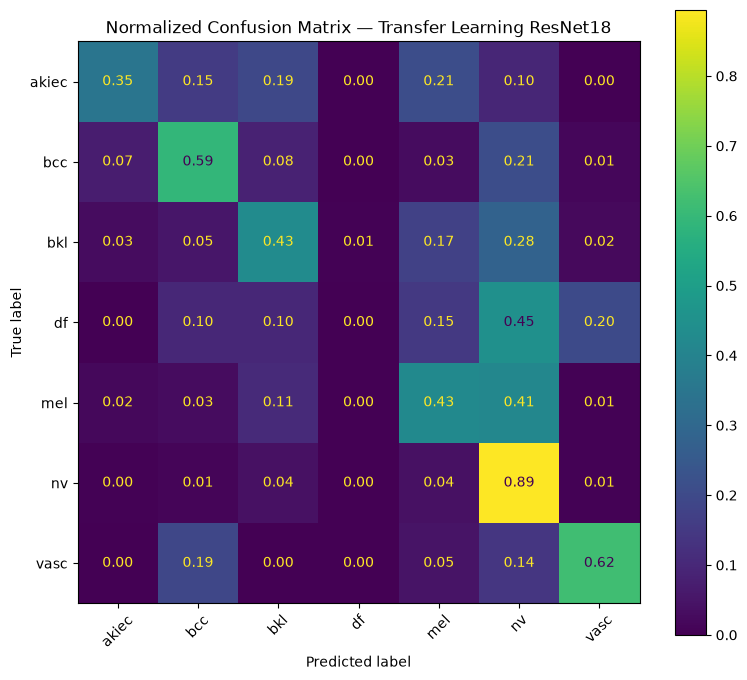

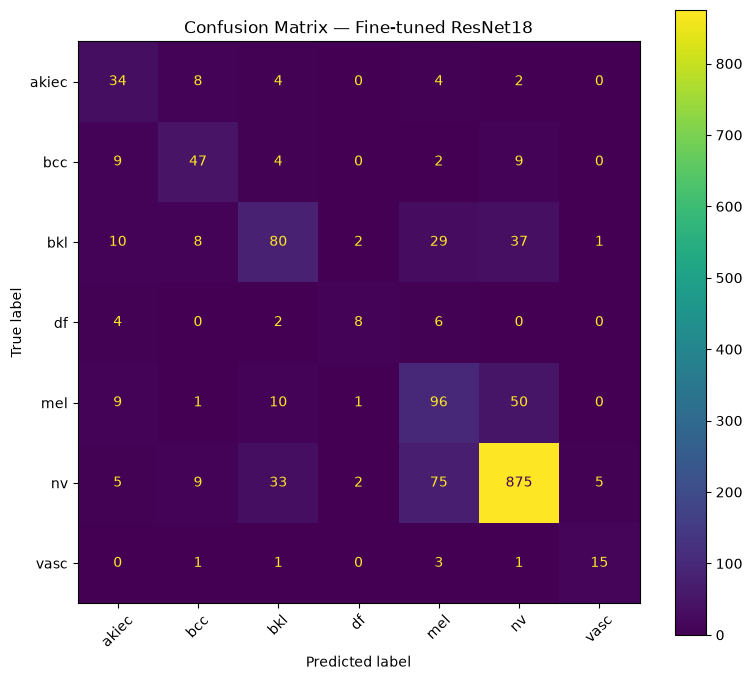

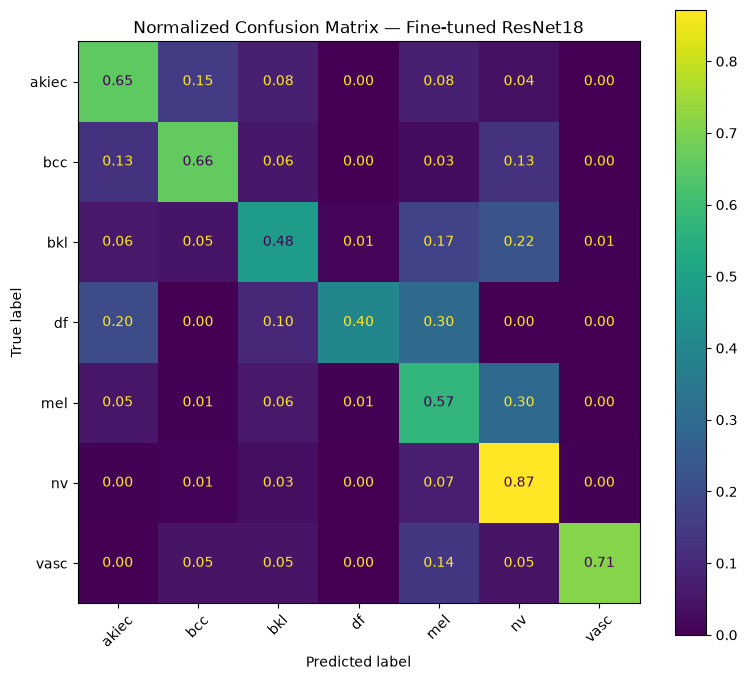

In [12]:
for name,df in prediction_tables.items():
    for normalized in (False,True):
        cm=normalized_confusion_matrix(df,CLASS_NAMES) if normalized else confusion_count_matrix(df,CLASS_NAMES)
        fig,ax=plt.subplots(figsize=(8,7)); ConfusionMatrixDisplay(cm,display_labels=CLASS_NAMES).plot(ax=ax,values_format=".2f" if normalized else "d",xticks_rotation=45); ax.set_title(("Normalized " if normalized else "")+f"Confusion Matrix — {name}"); fig.tight_layout(); fn=name.lower().replace(" ","_").replace("-","_")+('_normalized_cm.png' if normalized else '_cm.png'); fig.savefig(FIGURE_DIR/fn,dpi=200,bbox_inches="tight"); plt.show()


## 5. Common confusion pairs


In [13]:
confusion_pair_tables={}
for name,df in prediction_tables.items():
    p=common_confusion_pairs(df,10); confusion_pair_tables[name]=p; print("\n",name); display(p)



 Simple CNN


,true_class,pred_class,count,mean_confidence,max_confidence
0,nv,mel,195,0.446284,0.772283
1,nv,bkl,93,0.427009,0.895913
2,bkl,mel,36,0.439956,0.661169
3,nv,bcc,34,0.311395,0.445801
4,mel,bkl,25,0.459595,0.605717
5,bcc,akiec,25,0.355199,0.555952
6,bkl,nv,23,0.546446,0.987581
7,mel,akiec,20,0.358230,0.496994
8,nv,akiec,20,0.315027,0.521560
9,bkl,akiec,19,0.319681,0.416302



 Complex CNN


,true_class,pred_class,count,mean_confidence,max_confidence
0,mel,nv,76,0.507463,0.859302
1,bkl,nv,55,0.531691,0.865622
2,nv,bkl,34,0.377899,0.746324
3,nv,mel,32,0.356744,0.594600
4,mel,bkl,27,0.413280,0.611821
5,nv,bcc,22,0.346292,0.572286
6,bkl,mel,19,0.398910,0.594480
7,bkl,bcc,19,0.376835,0.680084
8,akiec,bcc,17,0.396794,0.621744
9,mel,bcc,11,0.348503,0.662588



 Transfer Learning ResNet18


,true_class,pred_class,count,mean_confidence,max_confidence
0,mel,nv,69,0.522897,0.819008
1,bkl,nv,47,0.474608,0.884704
2,nv,mel,42,0.412710,0.641067
3,nv,bkl,40,0.414016,0.738988
4,bkl,mel,29,0.420687,0.628069
5,mel,bkl,18,0.435268,0.580491
6,bcc,nv,15,0.457119,0.633076
7,nv,bcc,13,0.380724,0.533081
8,akiec,mel,11,0.370103,0.499738
9,akiec,bkl,10,0.356675,0.594489



 Fine-tuned ResNet18


,true_class,pred_class,count,mean_confidence,max_confidence
0,nv,mel,75,0.510714,0.910881
1,mel,nv,50,0.575895,0.847890
2,bkl,nv,37,0.529712,0.923144
3,nv,bkl,33,0.491902,0.955226
4,bkl,mel,29,0.506105,0.709231
5,bkl,akiec,10,0.476481,0.817390
6,mel,bkl,10,0.412844,0.616877
7,bcc,akiec,9,0.553323,0.798887
8,mel,akiec,9,0.527205,0.718494
9,bcc,nv,9,0.502525,0.765197


## 6. High-confidence errors (wrong but confidence ≥ 0.80)


In [14]:
rows=[]
for name,df in prediction_tables.items():
    h=high_confidence_errors(df,HIGH_CONF_THRESHOLD); total=int((~df.is_correct).sum()); rows.append({"model":name,"high_confidence_errors":len(h),"total_errors":total,"share":len(h)/total if total else np.nan})
high_conf_summary_df=pd.DataFrame(rows); display(high_conf_summary_df); high_conf_summary_df.to_csv(TABLE_DIR/"high_confidence_error_summary.csv",index=False)


,model,high_confidence_errors,total_errors,share
0,Simple CNN,13,600,0.021667
1,Complex CNN,13,415,0.031325
2,Transfer Learning ResNet18,3,388,0.007732
3,Fine-tuned ResNet18,19,347,0.054755


## 7. Visualize misclassified images


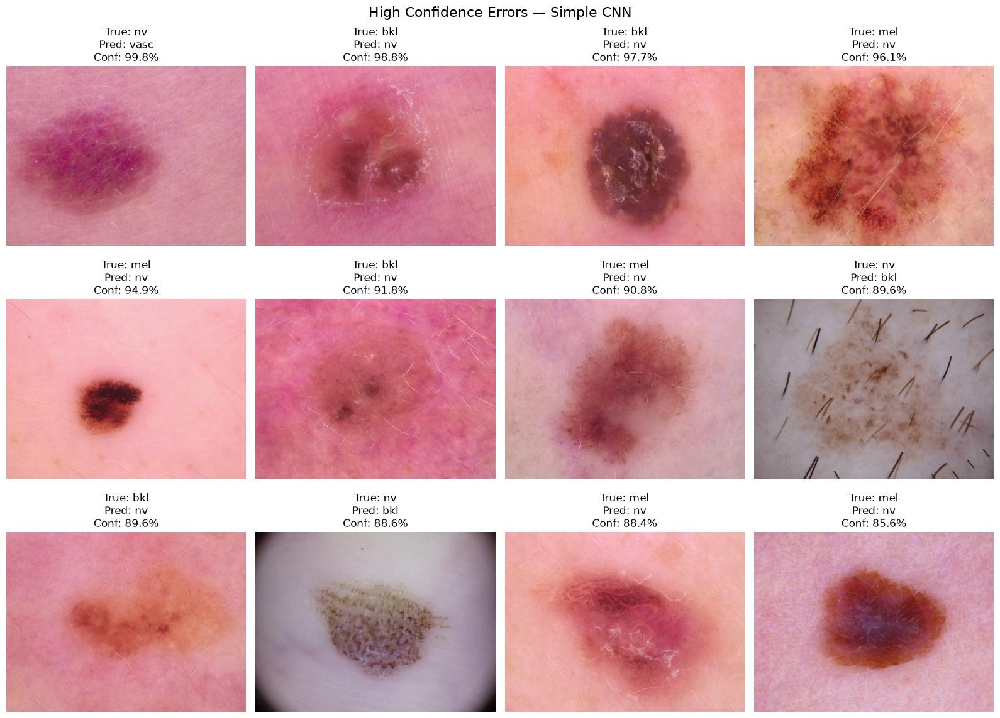

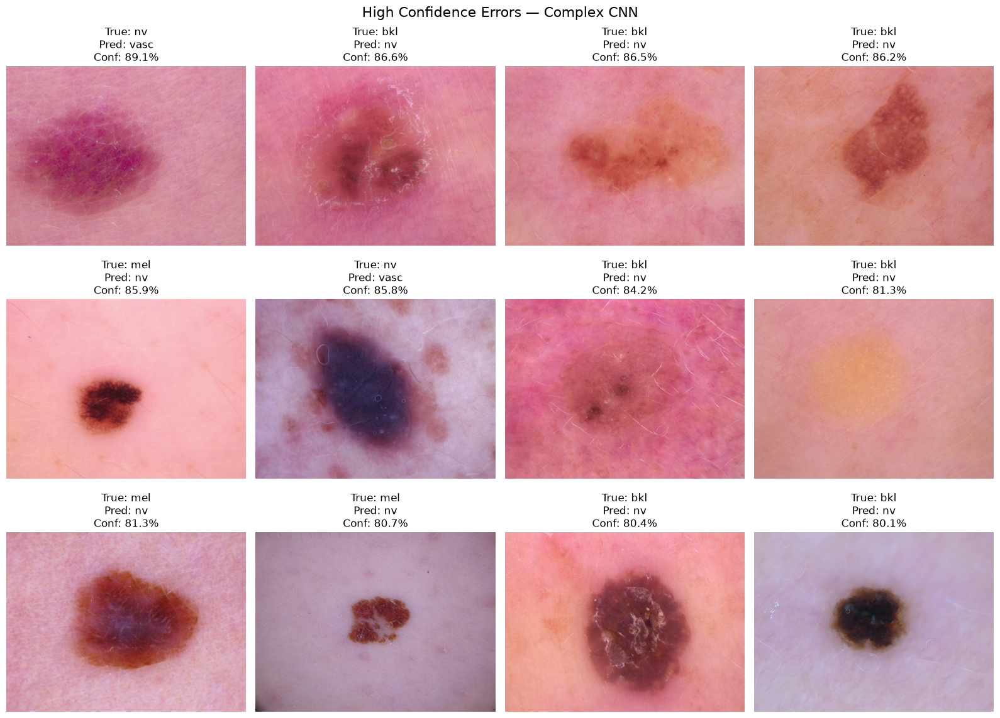

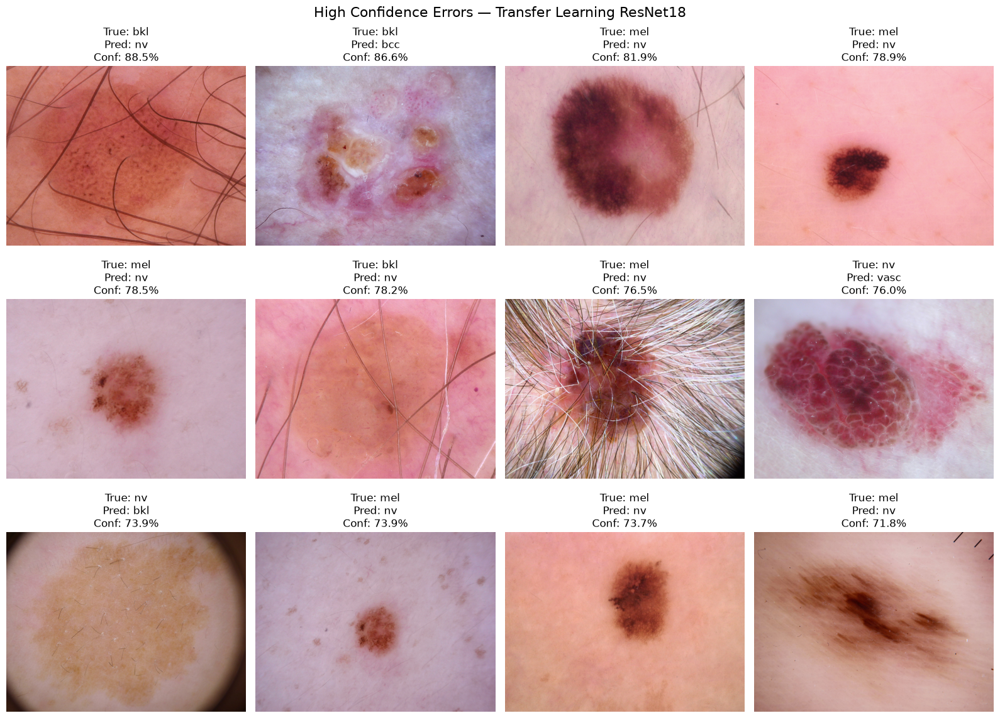

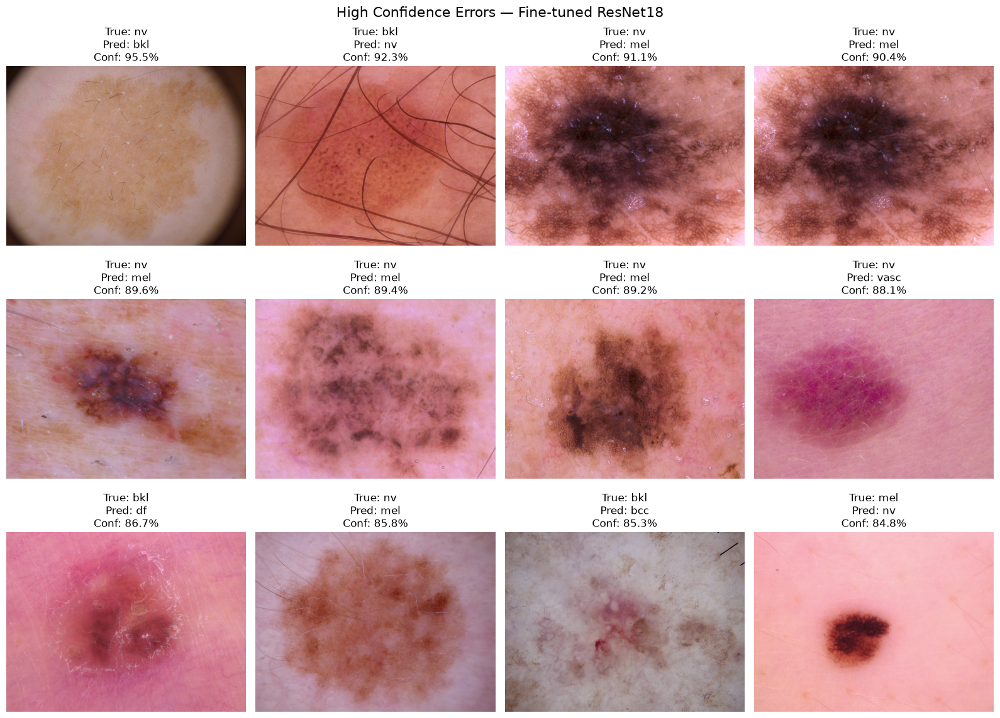

In [15]:
def show_error_images(df,title,n=12,sort_by="confidence",ascending=False):
    e=df[~df.is_correct].sort_values(sort_by,ascending=ascending).head(n)
    if e.empty: print("No errors"); return
    cols=4; rows=math.ceil(len(e)/cols); fig,axes=plt.subplots(rows,cols,figsize=(16,4*rows)); axes=np.atleast_1d(axes).ravel()
    for ax in axes: ax.axis("off")
    for ax,(_,r) in zip(axes,e.iterrows()):
        img=Image.open(resolve_image_path(r,DATA_ROOT)).convert("RGB"); ax.imshow(img); ax.set_title(f"True: {r.true_class}\nPred: {r.pred_class}\nConf: {r.confidence:.1%}"); ax.axis("off")
    fig.suptitle(title,fontsize=16); fig.tight_layout(); fn=title.lower().replace(" ","_").replace("—","").replace("-","_")+".png"; fig.savefig(FIGURE_DIR/fn,dpi=200,bbox_inches="tight"); plt.show()
for name,df in prediction_tables.items(): show_error_images(df,f"High Confidence Errors — {name}")


## 8. Low-confidence / uncertain predictions


In [16]:
rows=[]
for name,df in prediction_tables.items():
    x=low_confidence_predictions(df,LOW_CONF_THRESHOLD); rows.append({"model":name,"n_low_confidence":len(x),"share_low_confidence":len(x)/len(df),"accuracy_in_subset":x.is_correct.mean() if len(x) else np.nan})
low_conf_summary_df=pd.DataFrame(rows); display(low_conf_summary_df); low_conf_summary_df.to_csv(TABLE_DIR/"low_confidence_summary.csv",index=False)


,model,n_low_confidence,share_low_confidence,accuracy_in_subset
0,Simple CNN,735,0.489348,0.360544
1,Complex CNN,592,0.394141,0.476351
2,Transfer Learning ResNet18,586,0.390146,0.510239
3,Fine-tuned ResNet18,345,0.229694,0.437681


## 9. Shared errors across models


In [17]:
shared=test_df.reset_index(drop=True).copy()
for name,df in prediction_tables.items():
    safe=name.lower().replace(" ","_").replace("-","_"); aligned=df.set_index("image_id").reindex(shared.image_id); shared[f"{safe}_correct"]=aligned.is_correct.to_numpy()
correct_cols=[c for c in shared.columns if c.endswith("_correct")]; shared["n_models_wrong"]=(~shared[correct_cols].astype(bool)).sum(axis=1); shared["all_models_wrong"]=shared.n_models_wrong==len(models)
print("Images all models got wrong:",int(shared.all_models_wrong.sum())); display(shared.sort_values("n_models_wrong",ascending=False)[["image_id","dx","n_models_wrong","all_models_wrong"]+correct_cols].head(20)); shared.to_csv(TABLE_DIR/"cross_model_shared_errors.csv",index=False)


Images all models got wrong: 144


,image_id,dx,n_models_wrong,all_models_wrong,simple_cnn_correct,complex_cnn_correct,transfer_learning_resnet18_correct,fine_tuned_resnet18_correct
298,ISIC_0029502,mel,4,True,False,False,False,False
8,ISIC_0025076,bkl,4,True,False,False,False,False
274,ISIC_0033524,mel,4,True,False,False,False,False
307,ISIC_0030192,mel,4,True,False,False,False,False
11,ISIC_0030105,bkl,4,True,False,False,False,False
54,ISIC_0024711,bkl,4,True,False,False,False,False
56,ISIC_0027042,bkl,4,True,False,False,False,False
1028,ISIC_0032096,nv,4,True,False,False,False,False
1257,ISIC_0027150,nv,4,True,False,False,False,False
318,ISIC_0026604,mel,4,True,False,False,False,False


## 10. Save detailed model-specific tables


In [18]:
for name,df in prediction_tables.items():
    print(name,save_error_analysis_tables(df,TABLE_DIR,name,HIGH_CONF_THRESHOLD))


Simple CNN {'predictions': WindowsPath('c:/Deep Learning/skin-lesion-classification/outputs/error_analysis/tables/simple_cnn_predictions.csv'), 'class_errors': WindowsPath('c:/Deep Learning/skin-lesion-classification/outputs/error_analysis/tables/simple_cnn_class_errors.csv'), 'confusion_pairs': WindowsPath('c:/Deep Learning/skin-lesion-classification/outputs/error_analysis/tables/simple_cnn_confusion_pairs.csv'), 'high_confidence_errors': WindowsPath('c:/Deep Learning/skin-lesion-classification/outputs/error_analysis/tables/simple_cnn_high_confidence_errors.csv')}
Complex CNN {'predictions': WindowsPath('c:/Deep Learning/skin-lesion-classification/outputs/error_analysis/tables/complex_cnn_predictions.csv'), 'class_errors': WindowsPath('c:/Deep Learning/skin-lesion-classification/outputs/error_analysis/tables/complex_cnn_class_errors.csv'), 'confusion_pairs': WindowsPath('c:/Deep Learning/skin-lesion-classification/outputs/error_analysis/tables/complex_cnn_confusion_pairs.csv'), 'high_

## 11. Automatic report summary


In [19]:
best=error_comparison_df.iloc[0]; worst=error_comparison_df.iloc[-1]
print("Lowest error:",best["model"],f"{best.error_rate:.2%}"); print("Highest error:",worst["model"],f"{worst.error_rate:.2%}")
for name in models:
    s=class_error_tables[name].sort_values("error_rate",ascending=False).iloc[0]; p=confusion_pair_tables[name]
    print(f"\n{name}"); print(f"- Highest class error: {s['class']} ({s['error_rate']:.2%})")
    if not p.empty: print(f"- Most common confusion: {p.iloc[0]['true_class']} -> {p.iloc[0]['pred_class']} ({int(p.iloc[0]['count'])} cases)")
    print(f"- High-confidence errors: {len(high_confidence_errors(prediction_tables[name],HIGH_CONF_THRESHOLD))}")
print("\nImages wrong for all models:",int(shared.all_models_wrong.sum()))


Lowest error: Fine-tuned ResNet18 23.10%
Highest error: Simple CNN 39.95%

Simple CNN
- Highest class error: df (85.00%)
- Most common confusion: nv -> mel (195 cases)
- High-confidence errors: 13

Complex CNN
- Highest class error: df (100.00%)
- Most common confusion: mel -> nv (76 cases)
- High-confidence errors: 13

Transfer Learning ResNet18
- Highest class error: df (100.00%)
- Most common confusion: mel -> nv (69 cases)
- High-confidence errors: 3

Fine-tuned ResNet18
- Highest class error: df (60.00%)
- Most common confusion: nv -> mel (75 cases)
- High-confidence errors: 19

Images wrong for all models: 144
